# Install and import required packages

In [ ]:
!pip install iterative-stratification Dataset evaluate wandb emoji pythainlp -q


In [ ]:
import re
import emoji
import unicodedata
import pandas as pd
import wandb
import os
import numpy as np
import random
import os
from sklearn.metrics import classification_report, f1_score
from transformers import AutoModelForSequenceClassification, AutoTokenizer, EarlyStoppingCallback, TrainingArguments, Trainer, DataCollatorWithPadding
from datasets import Dataset, DatasetDict
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader
from iterstrat.ml_stratifiers import MultilabelStratifiedShuffleSplit
from pythainlp.util import normalize, thai_digit_to_arabic_digit
import evaluate
pd.set_option('display.max_colwidth', None)

In [ ]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

In [ ]:
train_df = pd.read_csv('train.csv')

# Examining Data

In [ ]:
train_df.shape

In [ ]:
train_df.head()

In [ ]:
train_df.isnull().sum()

In [ ]:
label_cols = train_df.columns[2:14]
train_df[label_cols].apply(lambda col: col.value_counts(normalize=True))

In [ ]:
train_df[label_cols].apply(lambda col: col.value_counts())

### Drop missing and duplicated values

In [ ]:
train_df = train_df.dropna()
train_df.drop_duplicates(inplace=True)

In [ ]:
train_df.shape

##  Drop unused columns

In [ ]:
train_df.drop('id', axis=1, inplace=True)

# Text Preprocessing

In [ ]:
def text_processing(text):
    if not isinstance(text, str):
        return ""

    text = unicodedata.normalize('NFKC', text)
    text = thai_digit_to_arabic_digit(text)
    text = emoji.replace_emoji(text, replace='')

    text = re.sub(r'http\S+|www\S+', '', text)
    text = re.sub(r'[a-zA-Z0-9._%+-]+@[a-zA-Z0-9.-]+\.[a-zA-Z]{2,}', '', text)

    phone_pattern = r'\b0\d{1,2}[-.\s]?\d{3}[-.\s]?\d{3,4}\b'
    text = re.sub(phone_pattern, ' ', text)
    text = re.sub(r'[^\u0E00-\u0E7Fa-zA-Z0-9\s]', ' ', text)

    text = normalize(text)
    text = re.sub(r'\s+', ' ', text).strip()
    text = text.lower().strip()

    return text

train_df['clean_comment'] = train_df['comment'].apply(text_processing)

In [ ]:
train_df[['clean_comment', 'comment']].sample(5)

Save cleaned train_df

In [ ]:
train_df.to_csv('train_clean.csv', index=False)

# Splitting Data

In [ ]:
seed_value = 2103

def prepare_data(df, label_columns, ratio_neg=0.1, major_limit=8000, test_random=0,ratio=0.4):

    all = df.copy()
    class_counts = df[label_columns].sum()

    rare_cols = class_counts[class_counts < 2000].index
    rare_pos_df = df[df[rare_cols].any(axis=1)]

    all_common_pos_df = df[(df[label_columns].sum(axis=1) > 0) & (~df.index.isin(rare_pos_df.index))]
    common_sampled = all_common_pos_df.sample(n=min(len(all_common_pos_df), major_limit), random_state=seed_value)

    neg_df = df[df[label_columns].sum(axis=1) == 0]
    neg_sampled = neg_df.sample(n=min(len(neg_df), int(ratio_neg * len(neg_df))), random_state=seed_value)

    sampled_df = pd.concat([rare_pos_df, common_sampled, neg_sampled])
    remaining = all.drop(sampled_df.index)
    sampled_df = sampled_df.reset_index(drop=True)

    msss = MultilabelStratifiedShuffleSplit(n_splits=1, test_size=ratio, random_state=seed_value)

    X = sampled_df.drop(columns=label_columns)
    y = sampled_df[label_columns]

    for train_index, val_test_index in msss.split(X, y):
        train_set = sampled_df.iloc[train_index]
        val_test_set = sampled_df.iloc[val_test_index]

    msss = MultilabelStratifiedShuffleSplit(n_splits=1, test_size=0.5, random_state=seed_value)

    X = val_test_set.drop(columns=label_columns)
    y = val_test_set[label_columns]

    for val_index, test_index in msss.split(X, y):
        val_set = val_test_set.iloc[val_index]
        test_set = val_test_set.iloc[test_index]

    if test_random > 0:
      test_sampled = remaining.sample(n=min(len(remaining), test_random), random_state=seed_value)
      test_set = pd.concat([test_set, test_sampled]).sample(frac=1, random_state=seed_value).reset_index(drop=True)

    train_set = train_set.drop('comment', axis=1, )
    val_set = val_set.drop('comment', axis=1, )
    test_set = test_set.drop('comment', axis=1)

    return train_set, val_set, test_set

train_set, val_set, test_set = prepare_data(train_df, label_cols, ratio=0.2)

In [ ]:
train_set.shape, val_set.shape, test_set.shape

In [ ]:
train_set[label_cols].apply(lambda col: col.value_counts())

In [ ]:
val_set[label_cols].apply(lambda col: col.value_counts())

In [ ]:
test_set[label_cols].apply(lambda col: col.value_counts())

# Model

### Model Selection

In [ ]:
model_path =  "clicknext/phayathaibert"
classes = [col for col in train_set if col not in ['clean_comment']]
class2id = {class_name: idx for idx, class_name in enumerate(classes)}
id2class = {idx: class_name for class_name, idx in class2id.items()}

tokenizer = AutoTokenizer.from_pretrained(model_path)
model = AutoModelForSequenceClassification.from_pretrained(
    model_path,
    num_labels=len(classes),
    id2label=id2class,
    label2id=class2id,
    problem_type="multi_label_classification"
)

data_collator = DataCollatorWithPadding(tokenizer=tokenizer)

### Preprocessing

In [ ]:
def preprocess_function(example):
    text = example["clean_comment"]
    if text == None:
        text=""

    labels = [float(example[label]) for label in label_cols]

    tokenized = tokenizer(
        text,
        truncation=True,
        max_length=256
    )

    tokenized["labels"] = labels

    return tokenized

train_dataset = Dataset.from_pandas(train_set, preserve_index=False)
eval_dataset = Dataset.from_pandas(val_set, preserve_index=False)

dataset = DatasetDict({
    'train': train_dataset,
    'val': eval_dataset
})

tokenized_dataset = dataset.map(
    preprocess_function,
    remove_columns=dataset["train"].column_names
)


###  Focal Loss Function

In [ ]:
num_pos = train_set[label_cols].sum().values
total_samples = len(train_set)

alphas = np.log(total_samples / (num_pos + 1e-5))
alphas = alphas / alphas.sum() * len(num_pos)
alpha_tensor = torch.tensor(alphas, dtype=torch.float)

class FocalLoss(nn.Module):
    def __init__(self, alpha, gamma=2.0):
        super(FocalLoss, self).__init__()
        self.alpha = alpha
        self.gamma = gamma

    def forward(self, logits, targets):

        probs = torch.sigmoid(logits)
        bce_loss = F.binary_cross_entropy_with_logits(logits, targets, reduction='none')
        pt = torch.where(targets == 1, probs, 1 - probs)
        focal_loss = self.alpha * (1 - pt)**self.gamma * bce_loss

        return focal_loss.mean()

class MyTrainer(Trainer):
    def __init__(self, *args, pos_weights=None, **kwargs):
        super().__init__(*args, **kwargs)

        self.focal_loss_fct = FocalLoss(alpha=alpha_tensor)

    def compute_loss(self, model, inputs, return_outputs=False, **kwargs):
        labels = inputs.pop("labels")
        outputs = model(**inputs)
        logits = outputs.get("logits")

        if self.focal_loss_fct.alpha.device != logits.device:
          self.focal_loss_fct.alpha = self.focal_loss_fct.alpha.to(logits.device)

        loss = self.focal_loss_fct(logits, labels.float())

        return (loss, outputs) if return_outputs else loss

## Training Arguments

In [ ]:
folder_name = "Your_Model_Name"
os.environ["WANDB_API_KEY"] = "Your_Key"
wandb.login()

wandb.init(
    project="Your_Project _Name",
    name=folder_name
)
report_to = "wandb"
output_dir = folder_name

training_args = TrainingArguments(
    output_dir=output_dir,
    learning_rate=2e-5,
    per_device_train_batch_size=32,
    per_device_eval_batch_size=64,
    num_train_epochs=10,
    weight_decay=0.01,
    fp16=True,

    lr_scheduler_type="linear",
    warmup_steps=0,
    seed=42,
    data_seed=3407,

    logging_strategy="epoch",
    eval_strategy="epoch",
    save_strategy="epoch",
    save_total_limit=1,
    load_best_model_at_end=True,
    report_to=report_to
)

trainer = MyTrainer(
    model=model,
    args=training_args,
    train_dataset=tokenized_dataset["train"],
    eval_dataset=tokenized_dataset["val"],
    processing_class=tokenizer,
    data_collator=data_collator,
    callbacks=[EarlyStoppingCallback(early_stopping_patience=3)],
)

trainer.train()

## Training Loss And Validation Loss

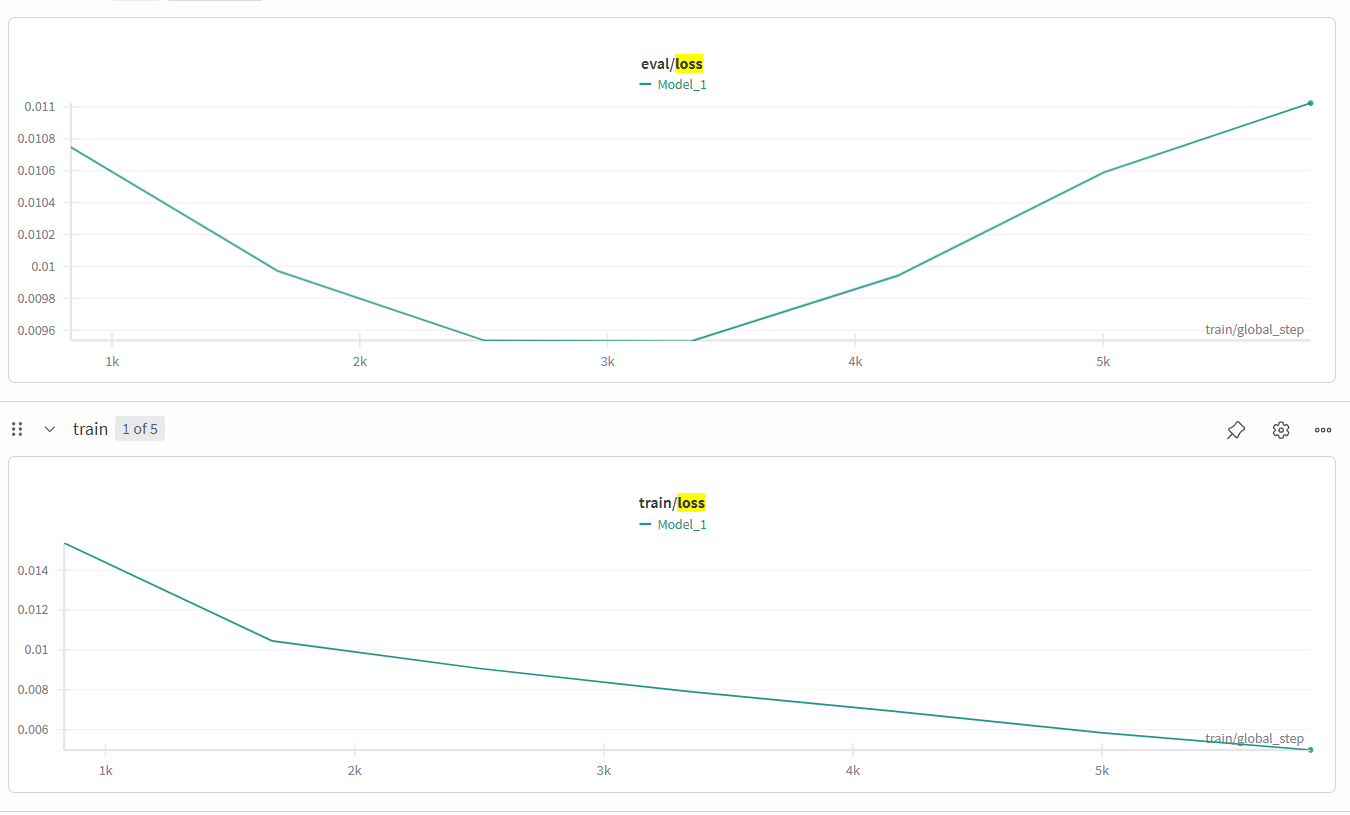

Save the best model

In [ ]:
wandb.finish()
trainer.save_model(output_dir)
tokenizer.save_pretrained(output_dir)

# Evaluation

In [ ]:
model = trainer.model
model.eval()
model.half()
model.to(device)

In [ ]:
test_dataset = Dataset.from_pandas(test_set)

tokenized_test_dataset = test_dataset.map(
    preprocess_function,
    remove_columns=test_dataset.column_names
)
data_collator = DataCollatorWithPadding(tokenizer=tokenizer)
test_loader = DataLoader(tokenized_test_dataset, batch_size=1024,shuffle=False, collate_fn=data_collator)

In [ ]:
all_probs = []
all_labels = []

with torch.no_grad():
    for batch in test_loader:

        batch = batch.to(device)
        if 'labels' in batch:
            all_labels.append(batch['labels'].cpu())

        outputs = model(**batch)
        logits = outputs.logits

        probs = torch.sigmoid(logits)

        all_probs.append(probs.cpu())

probs = torch.cat(all_probs).numpy()
y_true = torch.cat(all_labels).numpy() if all_labels else None


In [ ]:
def find_best_list_thresholds(probs, y_true):
  best_thresholds = []

  for i in range(len(classes)):
    y_true_col = y_true[:, i]
    y_prob_col = probs[:, i]

    best_f1 = 0
    current_best_t = 0.5

    for t_candidate in np.linspace(0.05, 1, 76):

        f1 = f1_score(y_true_col, (y_prob_col > t_candidate).astype(int), zero_division=0)

        if f1 > best_f1:
            best_f1 = f1
            current_best_t = t_candidate

    best_thresholds.append(current_best_t)
    print(f"Class: {classes[i]}  Best T: {current_best_t:.2f} , F1: {best_f1:.4f}")
  return best_thresholds

list_t =  find_best_list_thresholds(probs, y_true)

# Result In Test Set

In [ ]:
preds = (probs > list_t).astype(int)

report = classification_report(
    y_true,
    preds,
    target_names=classes,
    zero_division=0
)
print(report)

# Improvement

Collect More Positive Class Samples

- เนื่องจากบางคอลัมน์มี จำนวนตัวอย่างของ positive class น้อยเกินไป ทำให้โมเดลไม่สามารถเรียนรู้รูปแบบของ positive class ได้อย่างมีประสิทธิภาพ ส่งผลให้ค่า Macro F1-score ยังได้ไม่ดีพอ

- การเพิ่มจำนวน positive class samples จะช่วยให้โมเดลเห็นตัวอย่างที่หลากหลายมากขึ้น ทำให้เรียนรู้ลักษณะของ positive class ได้ดีขึ้น เเละทำให้การวัดผลเชื่อถือได้มากยิ่งขึ้น

Data Augmentation

- ในกรณีที่ไม่สามารถรวบรวมข้อมูลเพิ่มเติมได้ สามารถเพิ่มจำนวนข้อมูลของ positive class ได้ด้วยการทำ Data Augmentation เช่น
  - การปรับโครงสร้างประโยค
  - การลบคำที่ไม่ใช่คำสำคัญ
  - การแทนที่คำด้วยคำที่มีความหมายใกล้เคียง

- วิธีการนี้ช่วยสร้างตัวอย่างข้อมูลใหม่ที่ยังคงความหมายเดิมไว้ ทำให้โมเดลสามารถเรียนรู้ positive class ได้ดีขึ้น